In [6]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
from neoform.simulate import simulate_game_no_mull, simulate_starting_hand
from neoform.utils import parse_decklist

On the play simulations:


100%|██████████| 50000/50000 [00:26<00:00, 1895.80it/s]


This list wins on average on turn : 4.771056644639423, median : 4.0


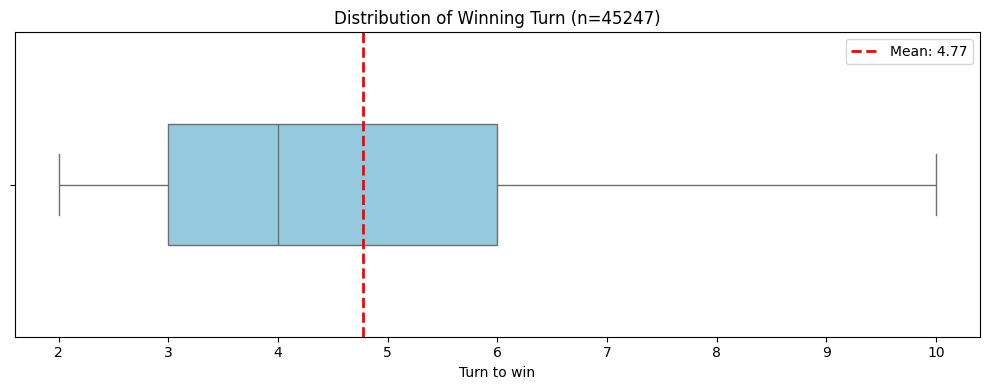

Wins on turn 2: 8015/50000 -> 16.03% of all games
Wins on or before turn 3: 16001/50000 -> 32.00% of all games
Standard deviation of winning turn: 2.2858


In [7]:
deck_list_str = """
4 Allosaurus Rider
1 Atraxa, Grand Unifier
1 Boseiju, Who Endures
1 Breeding Pool
1 Bridgeworks Battle
4 Consign to Memory
2 Disciple of Freyalise
4 Eldritch Evolution
1 Endurance
1 Flooded Strand
1 Generous Ent
2 Ghalta, Stampede Tyrant
1 Griselbrand
3 Hedge Maze
1 Hooting Mandrills
4 Misty Rainforest
4 Neoform
2 Nourishing Shoal
4 Pact of Negation
4 Planar Genesis
1 Scalding Tarn
2 Snow-Covered Forest
1 Snow-Covered Island
4 Summoner's Pact
1 Ureni, the Song Unending
3 Veil of Summer
1 Wooded Foothills
1 Xenagos, God of Revels
"""

deck_list = parse_decklist(deck_list_str)

n_sims = 50000
n_jobs = 1  # set to desired number of parallel workers, -1 uses all cores

on_the_play = True  # set to False to simulate games on the draw

print(f'{"On the play" if on_the_play else "On the draw"} simulations:')
# run simulations in parallel
results = Parallel(n_jobs=n_jobs)(
    delayed(simulate_game_no_mull)(deck_list, on_the_play=on_the_play) for _ in tqdm(range(n_sims))
)

# extract the win turn (or None) from each result
win = [res[0] if res is not None else None for res in results]

win = np.array(win, dtype=float)
average_turn_win = np.nanmean(win)
median_turn_win = np.nanmedian(win)

print(f'This list wins on average on turn : {average_turn_win}, median : {median_turn_win}')

# clean NaNs (games that didn't win)
wins_clean = win[~np.isnan(win)]

plt.figure(figsize=(10, 4))
ax = sns.boxplot(x=wins_clean, color="skyblue", width=0.4)

ax.set_xlabel("Turn to win")
ax.set_title(f"Distribution of Winning Turn (n={len(wins_clean)})")

# annotate mean and median
ax.axvline(average_turn_win, color="red", linestyle="--", linewidth=2, label=f"Mean: {average_turn_win:.2f}")
# ax.axvline(median_turn_win, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_turn_win:.0f}")

ax.legend()
plt.tight_layout()
plt.show()

count_turn2 = int(np.sum(win == 2))
pct_of_all = count_turn2 / win.size * 100
pct_of_wins = count_turn2 / wins_clean.size * 100 if wins_clean.size > 0 else np.nan

print(f"Wins on turn 2: {count_turn2}/{win.size} -> {pct_of_all:.2f}% of all games")

count_turn3 = int(np.sum(win <= 3))
pct_of_all_3 = count_turn3 / win.size * 100
pct_of_wins_3 = count_turn3 / wins_clean.size * 100 if wins_clean.size > 0 else np.nan

print(f"Wins on or before turn 3: {count_turn3}/{win.size} -> {pct_of_all_3:.2f}% of all games")
print(f"Standard deviation of winning turn: {np.std(wins_clean):.4f}")

On the play simulations:


100%|██████████| 50000/50000 [00:26<00:00, 1887.71it/s]


This list wins on average on turn : 4.593466695041498, median : 4.0


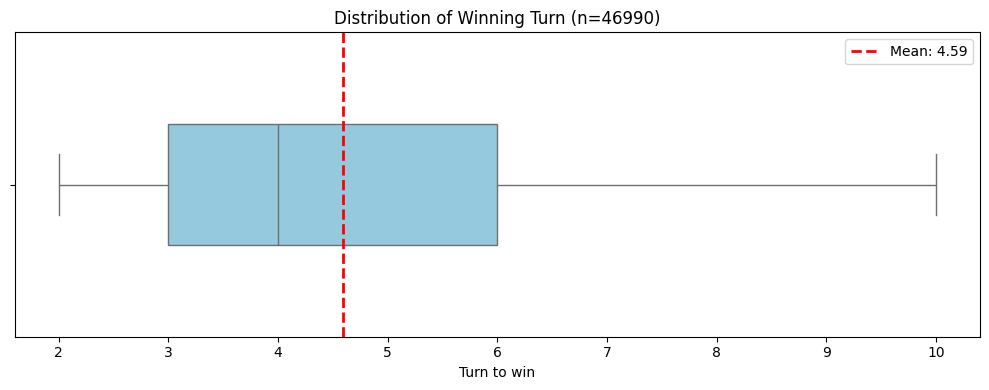

Wins on turn 2: 7654/50000 -> 15.31% of all games
Wins on or before turn 3: 17232/50000 -> 34.46% of all games
Standard deviation of winning turn: 2.1268


In [8]:
deck_list_str = """
4 Allosaurus Rider
1 Atraxa, Grand Unifier
2 Breeding Pool
4 Consign to Memory
1 Disciple of Freyalise
4 Eldritch Evolution
1 Flooded Strand
1 Generous Ent
2 Ghalta, Stampede Tyrant
1 Griselbrand
2 Hedge Maze
1 Hooting Mandrills
4 Misty Rainforest
4 Neoform
2 Nourishing Shoal
4 Pact of Negation
4 Planar Genesis
4 Preordain
2 Scalding Tarn
1 Snow-Covered Forest
2 Snow-Covered Island
2 Summoner's Pact
4 Veil of Summer
1 Wooded Foothills
1 Xenagos, God of Revels
"""

deck_list = parse_decklist(deck_list_str)

n_sims = 50000
n_jobs = 1  # set to desired number of parallel workers, -1 uses all cores

on_the_play = True  # set to False to simulate games on the draw

print(f'{"On the play" if on_the_play else "On the draw"} simulations:')
# run simulations in parallel
results = Parallel(n_jobs=n_jobs)(
    delayed(simulate_game_no_mull)(deck_list, on_the_play=on_the_play) for _ in tqdm(range(n_sims))
)

# extract the win turn (or None) from each result
win = [res[0] if res is not None else None for res in results]

win = np.array(win, dtype=float)
average_turn_win = np.nanmean(win)
median_turn_win = np.nanmedian(win)

print(f'This list wins on average on turn : {average_turn_win}, median : {median_turn_win}')

# clean NaNs (games that didn't win)
wins_clean = win[~np.isnan(win)]

plt.figure(figsize=(10, 4))
ax = sns.boxplot(x=wins_clean, color="skyblue", width=0.4)

ax.set_xlabel("Turn to win")
ax.set_title(f"Distribution of Winning Turn (n={len(wins_clean)})")

# annotate mean and median
ax.axvline(average_turn_win, color="red", linestyle="--", linewidth=2, label=f"Mean: {average_turn_win:.2f}")
# ax.axvline(median_turn_win, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_turn_win:.0f}")

ax.legend()
plt.tight_layout()
plt.show()

count_turn2 = int(np.sum(win == 2))
pct_of_all = count_turn2 / win.size * 100
pct_of_wins = count_turn2 / wins_clean.size * 100 if wins_clean.size > 0 else np.nan

print(f"Wins on turn 2: {count_turn2}/{win.size} -> {pct_of_all:.2f}% of all games")

count_turn3 = int(np.sum(win <= 3))
pct_of_all_3 = count_turn3 / win.size * 100
pct_of_wins_3 = count_turn3 / wins_clean.size * 100 if wins_clean.size > 0 else np.nan

print(f"Wins on or before turn 3: {count_turn3}/{win.size} -> {pct_of_all_3:.2f}% of all games")
print(f"Standard deviation of winning turn: {np.std(wins_clean):.4f}")

100%|██████████| 10000/10000 [00:06<00:00, 1662.35it/s]


This list wins on average on turn : 4.977756593581188, median : 5.0


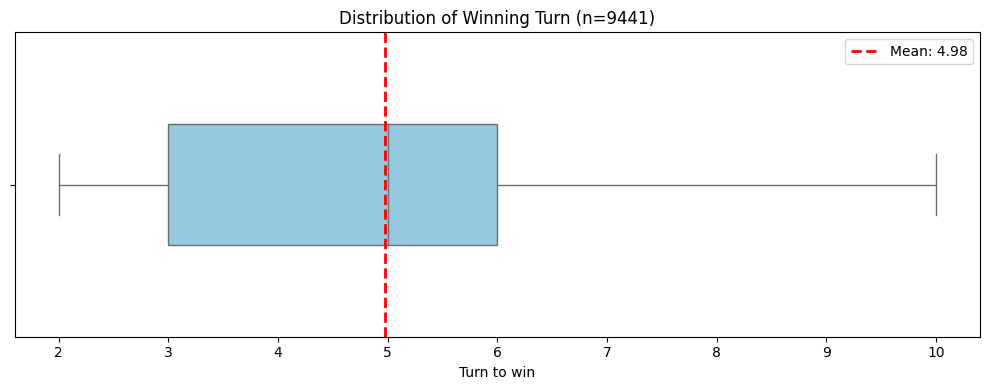

Wins on turn 2: 1030/10000 -> 10.30% of all games
Wins on or before turn 3: 2738/10000 -> 27.38% of all games
Standard deviation of winning turn: 2.1335


In [ ]:
deck_list_str = """
4 Allosaurus Rider
1 Atraxa, Grand Unifier
2 Breeding Pool
4 Consign to Memory
1 Disciple of Freyalise
4 Eldritch Evolution
1 Flooded Strand
1 Generous Ent
2 Ghalta, Stampede Tyrant
1 Griselbrand
2 Hedge Maze
1 Hooting Mandrills
4 Misty Rainforest
4 Neoform
2 Nourishing Shoal
4 Pact of Negation
4 Planar Genesis
4 Preordain
2 Scalding Tarn
1 Snow-Covered Forest
2 Snow-Covered Island
2 Summoner's Pact
4 Veil of Summer
1 Wooded Foothills
1 Xenagos, God of Revels
"""

starting_hand_str = """
1 Eldritch Evolution
1 Planar Genesis
1 Neoform
1 Allosaurus Rider
1 Disciple of Freyalise
1 Consign to Memory
"""

on_the_play = False

deck_list = parse_decklist(deck_list_str)
starting_hand = parse_decklist(starting_hand_str)

n_sims = 10000
n_jobs = 1  # set to desired number of parallel workers, -1 uses all cores

# run simulations in parallel
results = Parallel(n_jobs=n_jobs)(
    delayed(simulate_starting_hand)(starting_hand, deck_list, on_the_play = on_the_play) for _ in tqdm(range(n_sims))
)

# extract the win turn (or None) from each result
win = [res[0] if res is not None else None for res in results]

win = np.array(win, dtype=float)
average_turn_win = np.nanmean(win)
median_turn_win = np.nanmedian(win)

print(f'This hand wins on average on turn : {average_turn_win}, median : {median_turn_win}')

# clean NaNs (games that didn't win)
wins_clean = win[~np.isnan(win)]

plt.figure(figsize=(10, 4))
ax = sns.boxplot(x=wins_clean, color="skyblue", width=0.4)

ax.set_xlabel("Turn to win")
ax.set_title(f"Distribution of Winning Turn (n={len(wins_clean)})")

# annotate mean and median
ax.axvline(average_turn_win, color="red", linestyle="--", linewidth=2, label=f"Mean: {average_turn_win:.2f}")
# ax.axvline(median_turn_win, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_turn_win:.0f}")

ax.legend()
plt.tight_layout()
plt.show()

count_turn2 = int(np.sum(win == 2))
pct_of_all = count_turn2 / win.size * 100
pct_of_wins = count_turn2 / wins_clean.size * 100 if wins_clean.size > 0 else np.nan

print(f"Wins on turn 2: {count_turn2}/{win.size} -> {pct_of_all:.2f}% of all games")

count_turn3 = int(np.sum(win <= 3))
pct_of_all_3 = count_turn3 / win.size * 100
pct_of_wins_3 = count_turn3 / wins_clean.size * 100 if wins_clean.size > 0 else np.nan

print(f"Wins on or before turn 3: {count_turn3}/{win.size} -> {pct_of_all_3:.2f}% of all games")
print(f"Standard deviation of winning turn: {np.std(wins_clean):.4f}")